<a href="https://colab.research.google.com/github/monishaeswar/AI-Internship/blob/main/Random_Forest_Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("/content/train_loan.csv")

In [3]:
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [4]:
df = df.drop("Loan_ID", axis=1)

In [8]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [6]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [7]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [26]:
model.fit(X_train, y_train);

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7560975609756098


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [15]:
print(confusion_matrix(y_test, y_pred))

[[18 25]
 [ 5 75]]


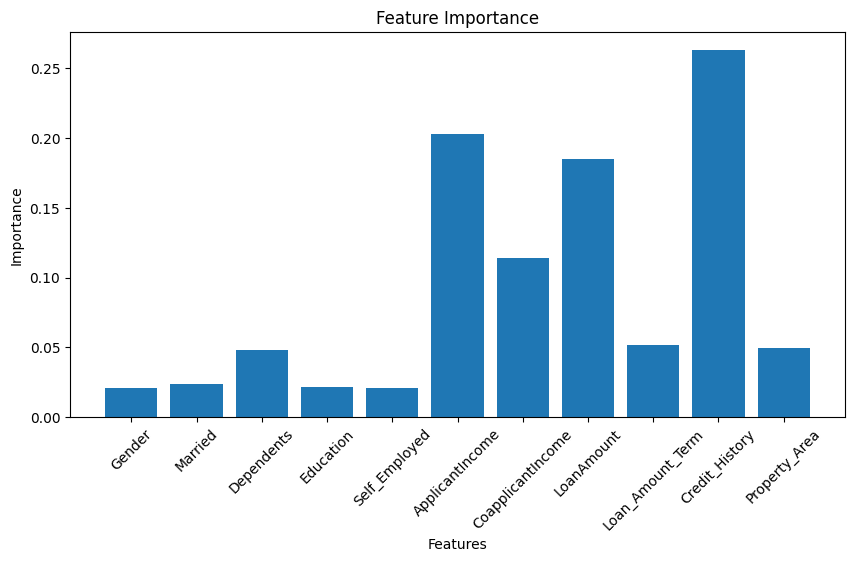

In [17]:
importance = model.feature_importances_
plt.figure(figsize=(10,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [19]:
new_applicant = pd.DataFrame([{
    "Gender": 1,
    "Married": 1,
    "Dependents": 0,
    "Education": 1,
    "Self_Employed": 0,
    "ApplicantIncome": 5000,
    "CoapplicantIncome": 2000,
    "LoanAmount": 150,
    "Loan_Amount_Term": 360,
    "Credit_History": 1,
    "Property_Area": 2
}])

prediction = model.predict(new_applicant)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


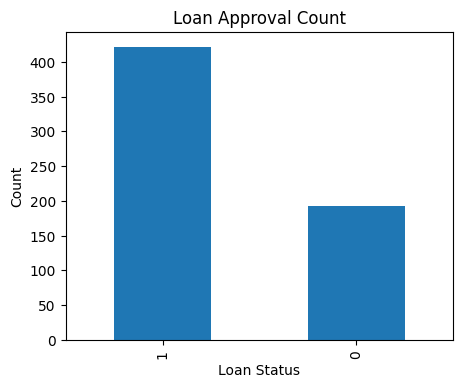

In [20]:
plt.figure(figsize=(5,4))
df["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Approval Count")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

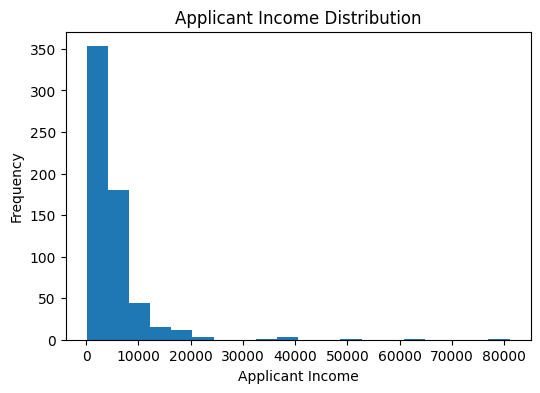

In [21]:
plt.figure(figsize=(6,4))
plt.hist(df["ApplicantIncome"], bins=20)
plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

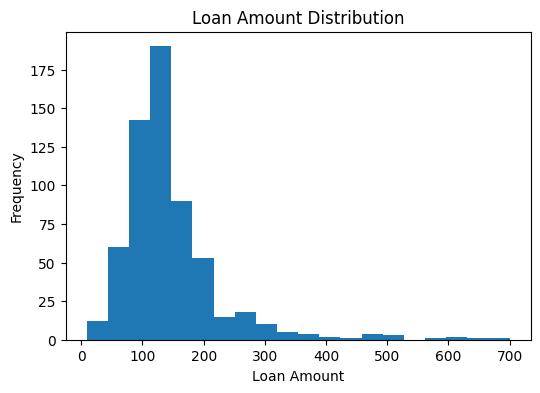

In [22]:
plt.figure(figsize=(6,4))
plt.hist(df["LoanAmount"], bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

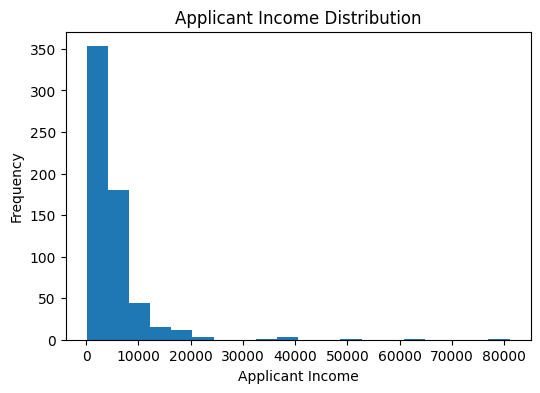

In [23]:
plt.figure(figsize=(6,4))
plt.hist(df["ApplicantIncome"], bins=20)
plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

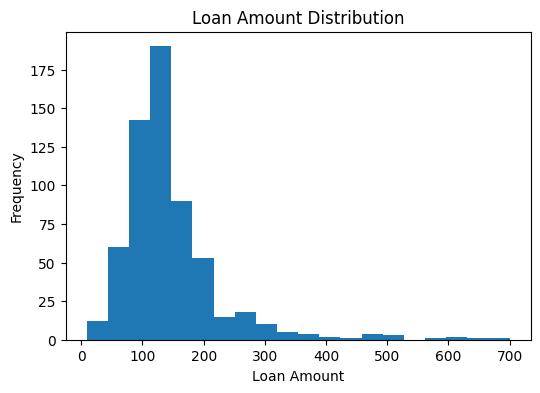

In [24]:
plt.figure(figsize=(6,4))
plt.hist(df["LoanAmount"], bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

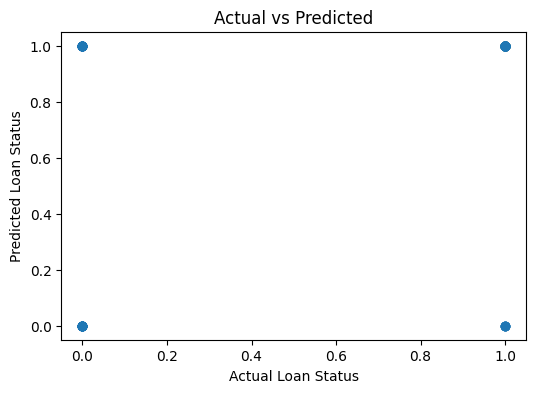

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted")
plt.xlabel("Actual Loan Status")
plt.ylabel("Predicted Loan Status")
plt.show()